# Sequence-model filters vs the Kalman filter vs an analytic Kalman transformer

Trains small sequence models — a Mistral-style transformer, a GPT-2-style
transformer and a Mamba-2 SSM — to estimate the state of a linear system from
noisy observations (the filtering problem), and compares them against the
model-based Kalman filter, which is optimal for this system and serves as the
baseline.

This variant additionally constructs the **analytic "Transformer Filter" of
Goel & Bartlett, *Can a Transformer Implement a Kalman Filter?*
(arXiv:2312.06937)**: a single causal self-attention layer whose weights are
set in closed form from the known system, so that softmax attention implements
Nadaraya-Watson Gaussian-kernel smoothing over the last H one-step Kalman
updates. With H = 1 the construction is *exactly* the steady-state Kalman
filter; for H > 1 it approximates it with an error controlled by the
temperature beta, uniformly in time (paper Theorem 2). Section 3 defines the
class, Section 11 builds and verifies it, and the analysis sections plot it
alongside every other method.

Based on `FilteringSequenceModels_clean.ipynb`.

**How to run:** execute all cells top to bottom. All experiment knobs live in
the `CONFIG` dict in the *Experiment* section.

**Requirements:** `torch`, `transformers`, `pytorch_lightning`, `filterpy`,
`scipy`, `tqdm`, `matplotlib`. `mamba_ssm` needs a CUDA GPU; on a CPU-only
machine set `selected_models = ['mistral', 'gpt2']`.

**Outputs:** Lightning logs and checkpoints under `lightning_logs/<model>/`,
evaluation plots inline, model checkpoints (`.pth`) in the working directory.


## 1. Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pytorch_lightning as pl
from pytorch_lightning import LightningModule
from transformers import GPT2Config, GPT2Model, MistralConfig, MistralModel
from mamba_ssm import Mamba2
from filterpy.kalman import KalmanFilter
from scipy.linalg import solve_discrete_are
import csv
from pathlib import Path

SEED = 42
# Seeds python / numpy / torch (and dataloader workers) so model init is reproducible.
pl.seed_everything(SEED, workers=True)
# Dedicated generator for all trajectory generation in this notebook.
rng = np.random.default_rng(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


/home/awt36/anaconda3/envs/MambaAMD/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading tilelang libs from dev root: /home/awt36/tilelang/build
Seed set to 42


Using device: cuda


## 2. System dynamics and Kalman-filter baseline

The plant is a discrete-time LTI system

```
x_{t+1} = A x_t + B u_t + w_t,   w_t ~ N(0, sigma_w^2 I)
y_t     = C x_t + v_t,           v_t ~ N(0, sigma_v^2 I)
```

with random stable/controllable/observable matrices when none are supplied.
The Kalman filter is given the true `(A, B, C)` and noise levels, so it is the
optimal filter for this system. The analytic transformer filter of Section 3
is given exactly the same information.


In [2]:
class FilterSim:
    """Discrete-time LTI system simulator.

    Args:
        nx, ny: state and output dimensions.
        sigma_w, sigma_v: process / measurement noise stds.
        A, B, C: system matrices; randomly generated (stable, controllable,
            observable) if not provided.
        eig_low, eig_high: eigenvalue range used when drawing A randomly.
        input_lower, input_upper: control-input distribution parameters (mean
            and per-dimension variance of the Gaussian input).
    """

    def __init__(self, nx=10, ny=5, sigma_w=0.1, sigma_v=0.1, A=None, B=None, C=None,
                 eig_low=0.5, eig_high=0.8, input_lower=0.0, input_upper=1.0):
        self.nx = nx
        self.ny = ny
        self.sigma_w = sigma_w
        self.sigma_v = sigma_v
        self.input_lower = input_lower
        self.input_upper = input_upper

        self.A = A if A is not None else self.random_stable_matrix(nx, eig_low, eig_high)
        self.B = B if B is not None else self.controllable_B(nx, self.A)
        self.C = C if C is not None else self.observable_C(nx, ny, self.A)

    @staticmethod
    def random_stable_matrix(n, eig_low=0.5, eig_high=0.8, max_tries=1000):
        """Random matrix with eigenvalues uniform in [eig_low, eig_high]."""
        for _ in range(max_tries):
            eigs = rng.uniform(eig_low, eig_high, size=n)
            P = rng.standard_normal(size=(n, n))
            if np.linalg.matrix_rank(P) == n:
                A = P @ np.diag(eigs) @ np.linalg.inv(P)
                if np.max(np.abs(np.linalg.eigvals(A))) < 0.95:
                    return A
        # Fallback: diagonal (always stable, exactly in the requested range).
        return np.diag(rng.uniform(eig_low, eig_high, size=n))

    @staticmethod
    def controllable_B(nx, A, max_tries=100):
        """Random B such that (A, B) is controllable."""
        for _ in range(max_tries):
            B = rng.standard_normal(size=(nx, nx))
            ctrb = np.concatenate([np.linalg.matrix_power(A, i) @ B for i in range(nx)], axis=1)
            if np.linalg.matrix_rank(ctrb) == nx:
                return B.astype(np.float32)
        raise RuntimeError("Could not generate a controllable B matrix")

    @staticmethod
    def observable_C(nx, ny, A, max_tries=100):
        """Random C such that (A, C) is observable."""
        for _ in range(max_tries):
            C = rng.standard_normal(size=(ny, nx))
            obsv = np.concatenate([C @ np.linalg.matrix_power(A, i) for i in range(nx)], axis=0)
            if np.linalg.matrix_rank(obsv) == nx:
                return C.astype(np.float32)
        raise RuntimeError("Could not generate an observable C matrix")

    def simulate(self, traj_len, x0=None, input_lower=None, input_upper=None):
        """Simulate one trajectory.

        Args:
            traj_len: number of state transitions; returned arrays have
                traj_len + 1 samples (x_0 .. x_T).
            x0: initial state, drawn from N(0, I) if None.
            input_lower: control-input mean (defaults to self.input_lower).
            input_upper: control-input per-dimension variance (defaults to
                self.input_upper), i.e. the inputs have std sqrt(input_upper).

        Returns:
            states:  (traj_len + 1, nx) true states.
            obs:     (traj_len + 1, ny) noisy observations.
            inputs:  (traj_len, nx) control inputs u_0 .. u_{T-1}.
        """
        nx, ny = self.nx, self.ny
        input_lower = self.input_lower if input_lower is None else input_lower
        input_upper = self.input_upper if input_upper is None else input_upper
        input_std = np.sqrt(input_upper)

        x = rng.standard_normal(size=nx) if x0 is None else x0
        states = [x]
        obs = [self.C @ x + rng.standard_normal(ny) * self.sigma_v]
        inputs = []

        for _ in range(traj_len):
            u = rng.normal(loc=input_lower, scale=input_std, size=nx)
            x = self.A @ x + self.B @ u + rng.standard_normal(size=nx) * self.sigma_w
            states.append(x)
            inputs.append(u)
            obs.append(self.C @ x + rng.standard_normal(ny) * self.sigma_v)

        return (np.array(states, dtype=np.float32),
                np.array(obs, dtype=np.float32),
                np.array(inputs, dtype=np.float32))


def apply_kalman_filter(A, B, C, obs, inputs=None, x0=None, P0=None,
                        sigma_w=0.1, sigma_v=0.1):
    """Run the model-based Kalman filter on one trajectory.

    Args:
        A, B, C: true system matrices.
        obs: (T + 1, ny) noisy observations y_0 .. y_T.
        inputs: (T, nx) control inputs u_0 .. u_{T-1}; assumed zero if None.
        x0, P0: initial state estimate / covariance (defaults: 0, I).
        sigma_w, sigma_v: process / measurement noise stds.

    Returns:
        (T + 1, nx) filtered state estimates x_hat_0 .. x_hat_T.
    """
    nx = A.shape[0]
    ny = C.shape[0]

    kf = KalmanFilter(dim_x=nx, dim_z=ny)
    kf.F, kf.B, kf.H = A, B, C
    kf.Q = np.eye(nx) * sigma_w ** 2
    kf.R = np.eye(ny) * sigma_v ** 2
    kf.P = np.eye(nx) if P0 is None else P0
    kf.x = np.zeros(nx) if x0 is None else x0

    kf_states = []
    kf.update(obs[0])  # initial measurement update -> x_hat_0
    kf_states.append(kf.x.copy())

    for t in range(len(obs) - 1):
        u = inputs[t] if inputs is not None else np.zeros(nx)
        kf.predict(u=u)       # x_hat_{t+1|t} = A x_hat_t + B u_t
        kf.update(obs[t + 1])  # incorporate y_{t+1}
        kf_states.append(kf.x.copy())

    return np.array(kf_states, dtype=np.float32)


def apply_kalman_filter_from_traj(traj):
    """Kalman-filter a trajectory dict produced by generate_trajectory()."""
    return apply_kalman_filter(
        traj['A'], traj['B'], traj['C'], traj['obs'], traj['inputs'],
        sigma_w=traj['sigma_w'], sigma_v=traj['sigma_v'])


def generate_trajectory(nx=10, ny=5, traj_len=50, sigma_w=0.1, sigma_v=0.1,
                         input_lower=0.0, input_upper=1.0, A=None, B=None, C=None,
                         eig_low=0.5, eig_high=0.8):
    """Generate one trajectory; a fresh random system is drawn for any of
    A/B/C that is None.

    Returns a dict with keys 'states', 'obs', 'inputs', 'A', 'B', 'C',
    'sigma_w', 'sigma_v'.
    """
    fsim = FilterSim(nx=nx, ny=ny, sigma_w=sigma_w, sigma_v=sigma_v, A=A, B=B, C=C,
                     eig_low=eig_low, eig_high=eig_high,
                     input_lower=input_lower, input_upper=input_upper)
    states, obs, inputs = fsim.simulate(traj_len)
    return {
        'states': states,
        'obs': obs,
        'inputs': inputs,
        'A': fsim.A,
        'B': fsim.B,
        'C': fsim.C,
        'sigma_w': sigma_w,
        'sigma_v': sigma_v,
    }

## 3. Analytic Kalman transformer filter (Goel & Bartlett)

Implements the "Transformer Filter" of Goel & Bartlett, *Can a Transformer
Implement a Kalman Filter?* (arXiv:2312.06937): a single causal self-attention
layer whose weights are set in **closed form** from the known system, so that
softmax attention computes Nadaraya-Watson Gaussian-kernel smoothing over the
last H one-step Kalman updates. With H = 1 (window = current token only) the
construction is *exactly* the steady-state Kalman filter; for H > 1 it
approximates it with an error controlled by the temperature beta, uniformly in
time (paper Theorem 2). Nothing in this class is trained.


In [3]:
class KalmanTransformerFilter:
    """Analytic single-layer causal transformer of Goel & Bartlett, 'Can a
    Transformer Implement a Kalman Filter?' (arXiv:2312.06937).

    Every weight is set in closed form from (A, B, C, sigma_w, sigma_v);
    nothing is trained:

      - read-in: the fixed quadratic feature embedding
        phi(z) = [1, z, {z_a * z_b : a <= b}], of dimension
        ell = 1 + nx + nx * (nx + 1) / 2;
      - one causal self-attention head over the last H tokens (the window
        includes the current token), with attention matrix A_attn chosen so
        that phi(q)^T A_attn phi(k) = -beta * ||q - k||^2 — i.e. softmax
        attention == Nadaraya-Watson smoothing with a Gaussian kernel of
        inverse bandwidth beta (paper Theorem 1);
      - value/output map M = [0 | I | 0], so M @ phi(x_tilde) = x_tilde;
      - identity MLP and no positional embedding.

    The estimate recursion is

        x_tilde_t = Abar @ x_hat_{t-1} + Bbar @ u_{t-1} + L @ y_t    (token t)
        x_hat_t   = sum_i softmax(-beta ||x_tilde_i - x_tilde_t||^2)_i x_tilde_i

    and with H = 1 this is *exactly* the steady-state Kalman filter.

    Deviations from the paper required by this notebook's setting:

      - inputs: the paper's filtering theorem is stated for
        x_{t+1} = A x_t + w_t, while the systems here are
        x_{t+1} = A x_t + B u_t + w_t, so the one-step update is the
        filtered-estimate observer form
        x_tilde_t = (I - LC) A x_hat_{t-1} + (I - LC) B u_{t-1} + L y_t;
      - indexing: the paper writes one-step *predictions*,
        x_tilde_i = (A - LC) x_hat_{i-1} + L y_{i-1}; here estimates are
        *filtered* (x_hat_t uses y_t) to align with the Kalman baseline and
        the trained sequence models, which are also evaluated on filtered
        estimates;
      - initialization: the paper initializes with the true x_0; the default
        here is x_hat_{-1} = 0, matching the information available to the
        Kalman baseline. filter(..., x0=...) reproduces the paper's oracle
        initialization;
      - applying the linear one-step update before the kernel is WLOG: phi of
        a linear map of the raw token is still a degree-<=2 polynomial of the
        raw token, which Theorem 1's quadratic-form attention represents.

    Args:
        A, B, C: true system matrices.
        sigma_w, sigma_v: process / measurement noise stds.
        H: causal attention window length; H=1 recovers the steady-state
            Kalman filter exactly.
        beta: softmax temperature (inverse Gaussian-kernel bandwidth).
        dtype: internal dtype for all computation; float64 is strongly
            recommended so that large-beta logit differences survive.
    """

    def __init__(self, A, B, C, sigma_w=0.01, sigma_v=0.01, H=4, beta=1e5,
                 dtype=np.float64):
        self.A = np.asarray(A, dtype=dtype)
        self.B = np.asarray(B, dtype=dtype)
        self.C = np.asarray(C, dtype=dtype)
        self.nx = self.A.shape[0]
        self.ny = self.C.shape[0]
        self.sigma_w = sigma_w
        self.sigma_v = sigma_v
        self.H = H
        self.beta = float(beta)
        self.dtype = dtype
        if H < 1:
            raise ValueError('H must be >= 1')

        # Steady-state Kalman quantities from the discrete algebraic Riccati
        # equation P = A P A' - A P C'(C P C' + R)^-1 C P A' + Q with gain
        # L = P C'(C P C' + R)^-1.  solve_discrete_are(a, b, q, r) solves
        # x = a'xa - a'xb(b'xb + r)^-1 b'xa + q, so pass a = A', b = C'.
        Q = sigma_w ** 2 * np.eye(self.nx, dtype=dtype)
        R = sigma_v ** 2 * np.eye(self.ny, dtype=dtype)
        self.P = solve_discrete_are(self.A.T, self.C.T, Q, R)
        self.L = self.P @ self.C.T @ np.linalg.inv(self.C @ self.P @ self.C.T + R)

        # Closed-loop observer matrices of the filtered-estimate recursion.
        self.Abar = (np.eye(self.nx) - self.L @ self.C) @ self.A   # = A - L C A
        self.Bbar = (np.eye(self.nx) - self.L @ self.C) @ self.B
        self.spectral_radius = float(np.max(np.abs(np.linalg.eigvals(self.Abar))))

        # --- Explicit transformer weights ------------------------------------
        # phi(z) = [1, z_1..z_n, {z_a * z_b : a <= b}]
        self.pairs = [(a, b) for a in range(self.nx) for b in range(a, self.nx)]
        self.pair_idx = {p: i for i, p in enumerate(self.pairs)}
        self.ell = 1 + self.nx + len(self.pairs)

        # A_attn: phi(q)' A_attn phi(k) = 2*beta*q.k - beta*q.q - beta*k.k
        #                                       = -beta * ||q - k||^2
        # (the q-only term cancels in the softmax but is kept so the logits are
        # exactly the Gaussian-kernel log-weights)
        A_attn = np.zeros((self.ell, self.ell), dtype=dtype)
        A_attn[1:self.nx + 1, 1:self.nx + 1] = 2.0 * self.beta * np.eye(self.nx)
        for b in range(self.nx):
            j = 1 + self.nx + self.pair_idx[(b, b)]
            A_attn[0, j] = -self.beta
            A_attn[j, 0] = -self.beta
        self.A_attn = A_attn

        # Value/output map: M @ phi(z) = z.
        self.M = np.zeros((self.nx, self.ell), dtype=dtype)
        self.M[:, 1:self.nx + 1] = np.eye(self.nx)

    def _phi(self, Z):
        """Fixed nonlinear read-in: [1, z, quadratic monomials of z]."""
        Z = np.atleast_2d(np.asarray(Z, dtype=self.dtype))
        quad = Z[:, [a for a, _ in self.pairs]] * Z[:, [b for _, b in self.pairs]]
        return np.concatenate(
            [np.ones((Z.shape[0], 1), dtype=self.dtype), Z, quad], axis=1)

    def _run(self, obs_seq, inputs_seq, use_attention=True, x0=None):
        """Causal forward pass with estimate feedback.

        Args:
            obs_seq: (T1, ny) observations in order.
            inputs_seq: inputs_seq[j] is applied between obs_seq[j] and
                obs_seq[j+1]; zeros if None.
            use_attention: compute the logits with the explicit attention
                weights (True) or directly as -beta*||q - k||^2 (False); the
                two are mathematically identical.
            x0: estimate before the first observation (default: zeros).

        Returns:
            (x_hats, x_tildes): (T1, nx) filtered estimates and one-step
            updates (tokens).
        """
        obs_seq = np.asarray(obs_seq, dtype=self.dtype)
        if inputs_seq is None:
            inputs_seq = np.zeros((obs_seq.shape[0], self.nx), dtype=self.dtype)
        else:
            inputs_seq = np.asarray(inputs_seq, dtype=self.dtype)

        x_hat = (np.zeros(self.nx, dtype=self.dtype) if x0 is None
                 else np.asarray(x0, dtype=self.dtype).copy())   # x_hat_{-1}
        x_tildes, x_hats = [], []
        for t in range(obs_seq.shape[0]):
            u_prev = inputs_seq[t - 1] if t >= 1 else np.zeros(self.nx, dtype=self.dtype)
            x_tilde = self.Abar @ x_hat + self.Bbar @ u_prev + self.L @ obs_seq[t]

            # Causal window of the last H one-step updates, including the
            # current token: the i = t self-term has kernel weight exp(0) and
            # dominates as beta grows; H = 1 keeps only it.
            window = np.stack(x_tildes[max(0, t - self.H + 1):] + [x_tilde])
            if use_attention:
                K = self._phi(window)                            # (w, ell) keys
                logits = K @ (self.A_attn @ self._phi(x_tilde)[0])
            else:
                logits = -self.beta * ((window - x_tilde) ** 2).sum(axis=1)
            logits = logits - logits.max()                       # self-term is 0
            alphas = np.exp(logits)
            alphas /= alphas.sum()

            x_hat = alphas @ window                              # sum_i alpha_i x_tilde_i
            x_tildes.append(x_tilde)
            x_hats.append(x_hat)
        return np.array(x_hats), np.array(x_tildes)

    def filter(self, obs, inputs=None, x0=None):
        """Filter one trajectory (same alignment as apply_kalman_filter).

        Args:
            obs: (T + 1, ny) observations y_0 .. y_T.
            inputs: (T, nx) control inputs u_0 .. u_{T-1}; zeros if None.
            x0: estimate before the first observation (default: zeros).

        Returns:
            (T + 1, nx) filtered estimates x_hat_0 .. x_hat_T.
        """
        x_hats, _ = self._run(obs, inputs, x0=x0)
        return x_hats

    def __call__(self, xs):
        """Trained-model interface: xs (1, T, ny + nx) tensor -> (1, T, nx).

        Row t of xs is (y_{t+1}, u_t) as produced by TrajectoryDataset, so
        y_0 is NOT available on this interface and the recursion starts from
        an estimate of zero just before y_1. Prefer filter(), which uses the
        full observation sequence including y_0.
        """
        device = xs.device if torch.is_tensor(xs) else None
        xs_np = (xs.detach().cpu().numpy() if torch.is_tensor(xs) else np.asarray(xs))
        if xs_np.ndim == 3:
            xs_np = xs_np[0]
        obs_seq = xs_np[:, :self.ny]      # y_1 .. y_T
        inp_seq = xs_np[:, self.ny:]      # u_0 .. u_{T-1}
        # Between y_1 and y_2 the applied input is u_1, so drop u_0.
        est = self._run(obs_seq, inp_seq[1:] if len(inp_seq) > 1 else None)[0]
        out = torch.from_numpy(est.astype(np.float32)).unsqueeze(0)
        return out.to(device) if device is not None and device.type != 'cpu' else out

    def verify_attention_identity(self, obs, inputs=None):
        """Max abs difference between the phi/A_attn attention path and the
        direct Gaussian-kernel path over one trajectory (Theorem 1 check)."""
        x1, _ = self._run(obs, inputs, use_attention=True)
        x2, _ = self._run(obs, inputs, use_attention=False)
        return float(np.max(np.abs(x1 - x2)))


## 4. Trajectory dataset

Each dataset item is one full trajectory. The model input at time t is
`[y_{t+1}, u_t]` (current observation and previous actuation) and the target is
the true state `x_{t+1}` — the causal filtering problem, so the models see
exactly what an online filter would see.

In [4]:
class TrajectoryDataset(Dataset):
    """Dataset of trajectories; each item is one full trajectory."""

    def __init__(self, trajectories):
        """
        Args:
            trajectories: list of trajectory dicts from generate_trajectory().
        """
        self.trajectories = trajectories

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]
        xs = np.concatenate([traj['obs'][1:], traj['inputs']], axis=-1)  # (T, ny + nx)
        ys = traj['states'][1:]                                         # (T, nx)
        return {
            'xs': torch.from_numpy(xs).float(),
            'ys': torch.from_numpy(ys).float(),
        }


def create_datasets(num_train=1000, num_val=200, traj_len=50, nx=10, ny=5,
                    sigma_w=0.1, sigma_v=0.1, input_lower=0.0, input_upper=1.0,
                    eig_low=0.5, eig_high=0.8, A=None, B=None, C=None):
    """Generate training and validation datasets for one system (A, B, C).

    Any of A/B/C left as None is drawn once per trajectory (i.e. each
    trajectory would come from a different random system).
    """
    kwargs = dict(nx=nx, ny=ny, traj_len=traj_len, sigma_w=sigma_w, sigma_v=sigma_v,
                  input_lower=input_lower, input_upper=input_upper,
                  eig_low=eig_low, eig_high=eig_high, A=A, B=B, C=C)
    print("Generating training trajectories...")
    train_trajectories = [generate_trajectory(**kwargs) for _ in tqdm(range(num_train))]
    print("Generating validation trajectories...")
    val_trajectories = [generate_trajectory(**kwargs) for _ in tqdm(range(num_val))]
    return TrajectoryDataset(train_trajectories), TrajectoryDataset(val_trajectories)

## 5. Models

All three models share the same Lightning plumbing (`SequenceFilterBase`):
AdamW + MSE loss on the next-state prediction task. They differ only in the
sequence backbone: Mistral-style and GPT-2-style transformer blocks (randomly
initialized from a small `transformers` config, fed via `inputs_embeds`) and a
stack of Mamba-2 SSM blocks.

In [5]:
class SequenceFilterBase(LightningModule):
    """Shared Lightning plumbing: MSE loss, logging and AdamW optimizer."""

    def __init__(self, input_dim, output_dim, learning_rate, weight_decay):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.criterion = nn.MSELoss()

    def _shared_step(self, batch, stage):
        preds = self(batch['xs'])
        ys = batch['ys']
        min_len = min(preds.shape[1], ys.shape[1])  # in case of n_positions truncation
        loss = self.criterion(preds[:, :min_len], ys[:, :min_len])
        self.log(f'{stage}_loss', loss, prog_bar=(stage == 'train'),
                 on_step=(stage == 'train'), on_epoch=True, sync_dist=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, 'train')

    def validation_step(self, batch, batch_idx):
        return self._shared_step(batch, 'val')

    def test_step(self, batch, batch_idx):
        return self._shared_step(batch, 'test')

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.learning_rate,
                                 weight_decay=self.weight_decay)


class MistralFilter(SequenceFilterBase):
    """Small randomly-initialized Mistral-style transformer used as a filter."""

    def __init__(self, input_dim, output_dim, n_positions=50, n_embd=128,
                 n_layer=6, n_head=4, dropout=0.15,
                 learning_rate=1e-4, weight_decay=1e-4):
        super().__init__(input_dim, output_dim, learning_rate, weight_decay)
        self.save_hyperparameters()
        self.n_positions = n_positions

        self.embed = nn.Linear(input_dim, n_embd)
        self.transformer = MistralModel(MistralConfig(
            vocab_size=1,                  # unused: we pass inputs_embeds directly
            max_position_embeddings=n_positions,
            hidden_size=n_embd,
            num_hidden_layers=n_layer,
            num_attention_heads=n_head,
            num_key_value_heads=n_head,    # no grouped-query attention
            intermediate_size=4 * n_embd,
            hidden_dropout=dropout,
            attention_dropout=dropout,
            use_cache=False,
        ))
        self.output_proj = nn.Linear(n_embd, output_dim)

    def forward(self, xs):
        x = self.embed(xs)
        if x.shape[1] > self.n_positions:  # keep only the most recent steps
            x = x[:, -self.n_positions:]
        hidden = self.transformer(inputs_embeds=x).last_hidden_state
        return self.output_proj(hidden)


class GPT2Filter(SequenceFilterBase):
    """Small randomly-initialized GPT-2-style transformer used as a filter."""

    def __init__(self, input_dim, output_dim, n_positions=50, n_embd=256,
                 n_layer=12, n_head=8, dropout=0.1,
                 learning_rate=3e-4, weight_decay=1e-2):
        super().__init__(input_dim, output_dim, learning_rate, weight_decay)
        self.save_hyperparameters()
        self.n_positions = n_positions

        self.embed = nn.Linear(input_dim, n_embd)
        self.transformer = GPT2Model(GPT2Config(
            n_positions=n_positions,
            n_embd=n_embd,
            n_layer=n_layer,
            n_head=n_head,
            resid_pdrop=dropout,
            embd_pdrop=dropout,
            attn_pdrop=dropout,
            use_cache=False,
        ))
        self.output_proj = nn.Linear(n_embd, output_dim)

    def forward(self, xs):
        x = self.embed(xs)
        if x.shape[1] > self.n_positions:
            x = x[:, -self.n_positions:]
        hidden = self.transformer(inputs_embeds=x).last_hidden_state
        return self.output_proj(hidden)


class MambaFilter(SequenceFilterBase):
    """Stack of Mamba-2 SSM blocks used as a filter."""

    def __init__(self, input_dim, output_dim, n_positions=50, d_model=256,
                 n_layers=4, d_state=16, d_conv=4, expand=2,
                 learning_rate=1e-4, weight_decay=1e-4):
        super().__init__(input_dim, output_dim, learning_rate, weight_decay)
        self.save_hyperparameters()
        self.n_positions = n_positions

        self.input_proj = nn.Linear(input_dim, d_model)
        self.input_ln = nn.LayerNorm(d_model)
        self.mamba_layers = nn.ModuleList([
            Mamba2(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)
            for _ in range(n_layers)
        ])
        self.layer_norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_layers)])
        self.output_proj = nn.Linear(d_model, output_dim)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, xs):
        x = self.input_ln(self.input_proj(xs))
        if x.shape[1] > self.n_positions:
            x = x[:, -self.n_positions:]
        for layer, layer_norm in zip(self.mamba_layers, self.layer_norms):
            x = layer_norm(layer(x))
        return self.output_proj(x)


MODEL_REGISTRY = {
    'mistral': MistralFilter,
    'gpt2': GPT2Filter,
    'mamba': MambaFilter,
}


def build_model(model_name, input_dim, output_dim, config):
    """Instantiate one of the supported filter models from a CONFIG dict."""
    if model_name == 'mistral':
        return MistralFilter(
            input_dim=input_dim, output_dim=output_dim,
            n_positions=config['n_positions'], n_embd=config['n_embd'],
            n_layer=config['n_layer'], n_head=config['n_head'],
            dropout=config['dropout'],
            learning_rate=config['learning_rate'], weight_decay=config['weight_decay'])
    if model_name == 'gpt2':
        return GPT2Filter(
            input_dim=input_dim, output_dim=output_dim,
            n_positions=config['n_positions'], n_embd=config['gpt2_n_embd'],
            n_layer=config['gpt2_n_layer'], n_head=config['gpt2_n_head'],
            dropout=config['gpt2_dropout'],
            learning_rate=config['gpt2_learning_rate'], weight_decay=config['gpt2_weight_decay'])
    if model_name == 'mamba':
        return MambaFilter(
            input_dim=input_dim, output_dim=output_dim,
            n_positions=config['n_positions'], d_model=config['d_model'],
            n_layers=config['n_layers'], d_state=config['d_state'],
            d_conv=config['d_conv'], expand=config['expand'],
            learning_rate=config['mamba_learning_rate'], weight_decay=config['mamba_weight_decay'])
    raise ValueError(f"Unknown model name {model_name!r}; expected one of {list(MODEL_REGISTRY)}")

## 6. Lightning data module

In [6]:
class TrajectoryDataModule(pl.LightningDataModule):
    """DataModule wrapping pre-generated trajectory datasets."""

    def __init__(self, train_dataset, val_dataset=None, test_dataset=None,
                 batch_size=32, num_workers=4):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.test_dataset = test_dataset
        self.batch_size = batch_size
        self.num_workers = num_workers

    def _loader(self, dataset, shuffle):
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=shuffle,
                          num_workers=self.num_workers, drop_last=False)

    def train_dataloader(self):
        return self._loader(self.train_dataset, shuffle=True)

    def val_dataloader(self):
        return self._loader(self.val_dataset, shuffle=False) \
            if self.val_dataset is not None else None

    def test_dataloader(self):
        return self._loader(self.test_dataset, shuffle=False) \
            if self.test_dataset is not None else None

## 7. Evaluation helpers

In [7]:
def generate_test_trajectories(config, A, B, C):
    """Generate test trajectories with the *_test entries of CONFIG on the
    training system (A, B, C)."""
    n = config['num_test']
    print(f"Generating {n} test trajectories...")
    return [
        generate_trajectory(
            nx=config['nx'], ny=config['ny'], traj_len=config['traj_len'],
            sigma_w=config['sigma_w_test'], sigma_v=config['sigma_v_test'],
            input_lower=config['input_lower_test'], input_upper=config['input_upper_test'],
            eig_low=config['eig_low_test'], eig_high=config['eig_high_test'],
            A=A, B=B, C=C)
        for _ in tqdm(range(n))
    ]


def run_model_inference(model, trajectories, batch_size=32, device=DEVICE):
    """Run a trained model over a list of trajectories (batched).

    Returns one (T, nx) numpy array of state predictions per trajectory,
    aligned with states[1:] of that trajectory.
    """
    model = model.to(device)
    model.eval()
    loader = DataLoader(TrajectoryDataset(trajectories), batch_size=batch_size,
                        shuffle=False, num_workers=0)
    predictions = []
    with torch.no_grad():
        for batch in loader:
            preds = model(batch['xs'].to(device))
            predictions.extend(preds.cpu().numpy())
    return predictions


def per_timestep_l2_errors(states_true, preds):
    """Per-time-step L2 norm of the state-estimation error for two aligned
    (T, nx) arrays (trimmed to the shorter length)."""
    n = min(len(states_true), len(preds))
    return np.linalg.norm(states_true[:n] - preds[:n], axis=-1)


def mean_std_curves(error_curves):
    """Trim a list of error curves to the shortest length and return the
    per-time-step (mean, std)."""
    n = min(len(c) for c in error_curves)
    trimmed = np.stack([c[:n] for c in error_curves])
    return trimmed.mean(axis=0), trimmed.std(axis=0)

---

# Experiment

Adjust `CONFIG` below, then run the remaining cells in order.

## 8. Configuration

In [ ]:
CONFIG = {
    # System dimensions
    'nx': 10,           # state dimension
    'ny': 5,            # output dimension

    # Dataset sizes and trajectory length
    'traj_len': 50,     # number of state transitions per trajectory
    'num_train': 15000,
    'num_val': 3750,
    'num_test': 5000,

    # Training system / noise (control inputs are Gaussian: input_*_train are
    # the mean and per-dimension variance)
    'sigma_w_train': 0.01,
    'sigma_v_train': 0.01,
    'input_lower_train': 0.0,
    'input_upper_train': 0.1,
    'eig_low_train': np.nextafter(0, 1),  # smallest positive float, avoids zero eigenvalues
    'eig_high_train': 0.9,

    # Test system / noise (can differ from training to test generalization)
    'sigma_w_test': 0.01,
    'sigma_v_test': 0.01,
    'input_lower_test': 0.0,
    'input_upper_test': 0.25,
    'eig_low_test': np.nextafter(0, 1),
    'eig_high_test': 0.9,

    # Mistral model
    'n_positions': 50,  # maximum sequence length (models see the most recent steps)
    'n_embd': 128,
    'n_layer': 6,
    'n_head': 4,
    'dropout': 0.15,

    # GPT-2 model
    'gpt2_n_embd': 128,
    'gpt2_n_layer': 6,
    'gpt2_n_head': 4,
    'gpt2_dropout': 0.1,

    # Mamba model
    'd_model': 128,
    'n_layers': 6,
    'd_state': 16,
    'd_conv': 4,
    'expand': 2,

    # Analytic Goel-Bartlett transformer filter (Section 3)
    'gb_H': 4,         # causal attention window (H=1 == steady-state Kalman filter)
    'gb_beta': 1e5,    # softmax temperature (inverse Gaussian-kernel bandwidth)

    # Training. num_epochs is the default for every model; the per-model
    # keys override it when set to a number (toggle to None to use the default).
    'batch_size': 32,
    'num_epochs': 75,
    'mistral_num_epochs': 100, # None,
    'gpt2_num_epochs': 26, # None,
    'mamba_num_epochs': 100, # None,
    'num_workers': 4,
    'learning_rate': 1e-4,       # Mistral
    'weight_decay': 1e-4,        # Mistral
    'gpt2_learning_rate': 1e-4,
    'gpt2_weight_decay': 1e-4,
    'mamba_learning_rate': 1e-4,
    'mamba_weight_decay': 1e-4,
    'gradient_clip': 1.0,
}

MODEL_DISPLAY_NAMES = {'mistral': 'Mistral', 'gpt2': 'GPT2', 'mamba': 'Mamba'}

print(f"Configuration: {CONFIG}")

## 9. Shared system and datasets

In [9]:
# One fixed system (A, B, C) shared by all training / validation / test
# trajectories. Eigenvalues are drawn from (0, 0.95).
A = FilterSim.random_stable_matrix(CONFIG['nx'],
                                   eig_low=np.nextafter(0, 1), eig_high=0.95)
B = FilterSim.controllable_B(CONFIG['nx'], A)
C = FilterSim.observable_C(CONFIG['nx'], CONFIG['ny'], A)

train_dataset, val_dataset = create_datasets(
    num_train=CONFIG['num_train'],
    num_val=CONFIG['num_val'],
    traj_len=CONFIG['traj_len'],
    nx=CONFIG['nx'],
    ny=CONFIG['ny'],
    sigma_w=CONFIG['sigma_w_train'],
    sigma_v=CONFIG['sigma_v_train'],
    input_lower=CONFIG['input_lower_train'],
    input_upper=CONFIG['input_upper_train'],
    A=A, B=B, C=C,
)
print(f"Train dataset: {len(train_dataset)} trajectories")
print(f"Val dataset:   {len(val_dataset)} trajectories")

Generating training trajectories...


100%|██████████| 15000/15000 [00:05<00:00, 2934.71it/s]


Generating validation trajectories...


100%|██████████| 3750/3750 [00:01<00:00, 2982.23it/s]

Train dataset: 15000 trajectories
Val dataset:   3750 trajectories


## 10. Model selection

In [10]:
# Which models to train: any subset of ['mistral', 'gpt2', 'mamba'].
selected_models = ['mistral', 'gpt2', 'mamba']

input_dim = CONFIG['ny'] + CONFIG['nx']
output_dim = CONFIG['nx']

models = {}
for name in selected_models:
    models[name] = build_model(name, input_dim, output_dim, CONFIG)
    n_params = sum(p.numel() for p in models[name].parameters())
    print(f"{MODEL_DISPLAY_NAMES[name]}: {n_params:,} parameters")

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 0), got 1. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 0), got 2. This may result in unexpected behavior.


Mistral: 1,577,994 parameters
GPT2: 7,632,522 parameters
Mamba: 632,850 parameters


## 11. Construct and verify the analytic filter

Builds the analytic filter of Section 3 on the shared system (A, B, C) with
the test noise levels, and verifies on a handful of trajectories that

1. the explicit attention weights reproduce the Gaussian-kernel logits
   exactly (paper Theorem 1),
2. with H = 1 the filter coincides with the steady-state Kalman filter,
3. the gap to the steady-state Kalman filter shrinks as beta grows and the
   window shrinks (paper Theorem 2).


attention feature dimension ell = 66
spectral radius of (I - LC)A    = 0.6983 (stable)
window H = 4, temperature beta = 100000

check 1  attention logits == -beta*||q - k||^2:  max|dx| = 0.00e+00
check 2  H=1 == steady-state Kalman filter:       max|dx| = 8.75e-07


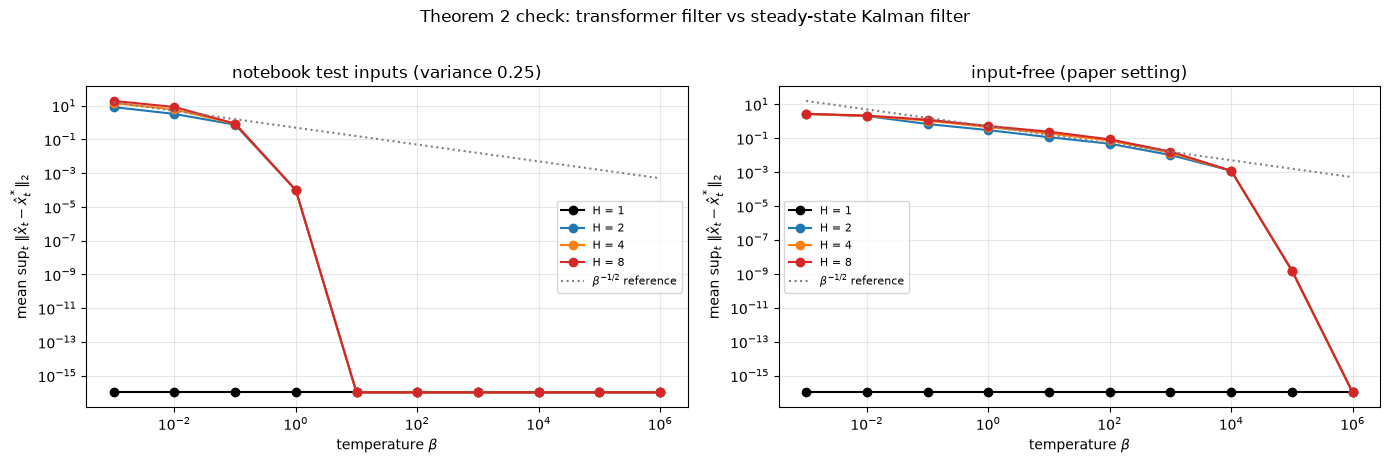

check 3  figure above: the gap is 0 for H = 1 and decays with beta for H > 1.
With this notebook's inputs the one-step-update tokens are far apart, so even
moderate beta collapses the kernel onto the current token (exact KF); the decay
is visible over the full beta range only in the input-free regime.


In [11]:
# The construction "knows" the true system (A, B, C) and the test noise
# levels; nothing is trained.
gb_filter = KalmanTransformerFilter(
    A, B, C, sigma_w=CONFIG['sigma_w_test'], sigma_v=CONFIG['sigma_v_test'],
    H=CONFIG['gb_H'], beta=CONFIG['gb_beta'])
# H = 1 keeps only the current token, so the softmax is degenerate and the
# filter is *exactly* the steady-state Kalman filter (beta is irrelevant);
# used below as the Theorem-2 reference x^*.
gb_filter_H1 = KalmanTransformerFilter(
    A, B, C, sigma_w=CONFIG['sigma_w_test'], sigma_v=CONFIG['sigma_v_test'],
    H=1, beta=1.0)

print(f"attention feature dimension ell = {gb_filter.ell}")
print(f"spectral radius of (I - LC)A    = {gb_filter.spectral_radius:.4f} "
      f"({'stable' if gb_filter.spectral_radius < 1 else 'UNSTABLE'})")
print(f"window H = {gb_filter.H}, temperature beta = {gb_filter.beta:g}")

verification_trajectories = [
    generate_trajectory(nx=CONFIG['nx'], ny=CONFIG['ny'], traj_len=CONFIG['traj_len'],
                        sigma_w=CONFIG['sigma_w_test'], sigma_v=CONFIG['sigma_v_test'],
                        input_lower=CONFIG['input_lower_test'],
                        input_upper=CONFIG['input_upper_test'], A=A, B=B, C=C)
    for _ in range(5)]

# Check 1 (paper Theorem 1): the explicit attention weights compute
# Gaussian-kernel logits exactly, i.e. softmax attention == Nadaraya-Watson
# smoothing.
identity_error = max(gb_filter.verify_attention_identity(t['obs'], t['inputs'])
                     for t in verification_trajectories)
print(f"\ncheck 1  attention logits == -beta*||q - k||^2:  max|dx| = {identity_error:.2e}")

# Check 2: with H = 1 the filter coincides with the steady-state Kalman
# filter (fixed DARE gain from t = 0), i.e. filterpy started at the DARE
# covariance.
kf_steady = apply_kalman_filter(
    A, B, C, verification_trajectories[0]['obs'], verification_trajectories[0]['inputs'],
    P0=gb_filter_H1.P, sigma_w=CONFIG['sigma_w_test'], sigma_v=CONFIG['sigma_v_test'])
h1 = gb_filter_H1.filter(verification_trajectories[0]['obs'],
                         verification_trajectories[0]['inputs'])
print(f"check 2  H=1 == steady-state Kalman filter:       max|dx| = "
      f"{np.max(np.abs(h1 - kf_steady)):.2e}")

# Check 3 (paper Theorem 2): the filter tracks the steady-state Kalman filter
# uniformly in time, with a gap that shrinks as beta grows (floored at machine
# precision for the loglog plot). Two regimes are swept: this notebook's test
# inputs (tokens far apart) and the paper's input-free setting (tokens close).
def theorem2_sweep(trajectories, windows, betas):
    reference = [gb_filter_H1.filter(t['obs'], t['inputs']) for t in trajectories]
    curves = {}
    for H in windows:
        errors = []
        for beta in betas:
            g = KalmanTransformerFilter(A, B, C, sigma_w=CONFIG['sigma_w_test'],
                                        sigma_v=CONFIG['sigma_v_test'], H=H, beta=beta)
            sup = [np.max(np.linalg.norm(g.filter(t['obs'], t['inputs']) - x_star, axis=1))
                   for t, x_star in zip(trajectories, reference)]
            errors.append(max(np.mean(sup), 1e-16))
        curves[H] = np.array(errors)
    return curves

betas = np.logspace(-3, 6, 10)
windows = [1, 2, 4, 8]
sweep_with_inputs = theorem2_sweep(verification_trajectories, windows, betas)
input_free_trajectories = [
    generate_trajectory(nx=CONFIG['nx'], ny=CONFIG['ny'], traj_len=CONFIG['traj_len'],
                        sigma_w=CONFIG['sigma_w_test'], sigma_v=CONFIG['sigma_v_test'],
                        input_lower=0.0, input_upper=0.0,  # no inputs (paper setting)
                        A=A, B=B, C=C)
    for _ in range(5)]
sweep_input_free = theorem2_sweep(input_free_trajectories, windows, betas)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
panels = [(axes[0], sweep_with_inputs,
           f"notebook test inputs (variance {CONFIG['input_upper_test']})"),
          (axes[1], sweep_input_free, "input-free (paper setting)")]
for ax, curves, title in panels:
    for H, color in zip(windows, ['k', 'tab:blue', 'tab:orange', 'tab:red']):
        ax.loglog(betas, curves[H], 'o-', color=color, label=f'H = {H}')
    ax.loglog(betas, 0.5 * betas ** -0.5, ':', color='gray',
              label=r'$\beta^{-1/2}$ reference')
    ax.set_xlabel(r'temperature $\beta$')
    ax.set_ylabel(r'mean sup$_t$ $\|\hat{x}_t - \hat{x}^*_t\|_2$')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle('Theorem 2 check: transformer filter vs steady-state Kalman filter', y=1.02)
plt.tight_layout()
plt.show()
print("check 3  figure above: the gap is 0 for H = 1 and decays with beta for H > 1.")
print("With this notebook's inputs the one-step-update tokens are far apart, so even")
print("moderate beta collapses the kernel onto the current token (exact KF); the decay")
print("is visible over the full beta range only in the input-free regime.")


## 12. Training

In [ ]:
datamodule = TrajectoryDataModule(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
)

model_trainers = {}
for name, model in models.items():
    # Per-model epoch override ({name}_num_epochs), falling back to num_epochs.
    n_epochs = CONFIG.get(f'{name}_num_epochs') or CONFIG['num_epochs']
    print(f"\nTraining {MODEL_DISPLAY_NAMES[name]} for {n_epochs} epochs...")
    trainer = pl.Trainer(
        max_epochs=n_epochs,
        accelerator='auto',
        devices='auto',
        gradient_clip_val=CONFIG['gradient_clip'],
        log_every_n_steps=50,
        logger=pl.loggers.CSVLogger('lightning_logs', name=name),
    )
    trainer.fit(model, datamodule=datamodule)
    best_score = trainer.checkpoint_callback.best_model_score
    message = f"{MODEL_DISPLAY_NAMES[name]} training complete."
    if best_score is not None:
        message += f" Best val loss: {best_score:.6f}"
    print(message)
    model_trainers[name] = trainer

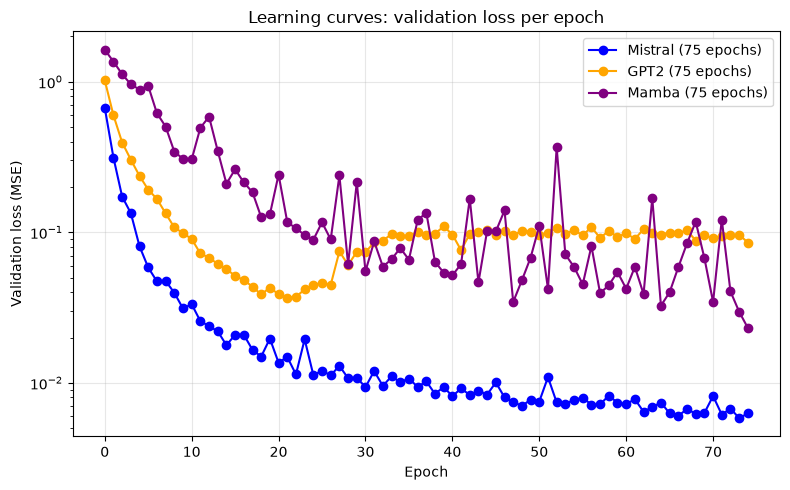

In [13]:
# Learning curves: validation loss per epoch for each model, read from the
# CSV logs Lightning wrote during training (lightning_logs/<model>/version_*).
def read_validation_curve(trainer):
    """(epochs, val_losses) from a trainer's CSVLogger metrics file."""
    metrics_file = Path(trainer.logger.log_dir) / 'metrics.csv'
    per_epoch = {}
    with open(metrics_file, newline='') as f:
        for row in csv.DictReader(f):
            value = row.get('val_loss')
            if value and value != 'nan':
                per_epoch[int(float(row['epoch']))] = float(value)
    epochs = sorted(per_epoch)
    return epochs, [per_epoch[e] for e in epochs]

model_colors = {'mistral': 'blue', 'gpt2': 'orange', 'mamba': 'purple'}

plt.figure(figsize=(8, 5))
for name, trainer in model_trainers.items():
    epochs, val_loss = read_validation_curve(trainer)
    plt.plot(epochs, val_loss, 'o-', color=model_colors.get(name, 'gray'),
             label=f'{MODEL_DISPLAY_NAMES[name]} ({len(epochs)} epochs)')
plt.xlabel('Epoch')
plt.ylabel('Validation loss (MSE)')
plt.yscale('log')
plt.title('Learning curves: validation loss per epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Load the best checkpoint of each model

In [26]:
trained_models = {}
for name, trainer in model_trainers.items():
    best_path = trainer.checkpoint_callback.best_model_path
    if not best_path:
        raise RuntimeError(f"No checkpoint was written for '{name}'.")
    trained_models[name] = MODEL_REGISTRY[name].load_from_checkpoint(best_path)
    trained_models[name].eval()
    print(f"Loaded best {name} checkpoint: {best_path}")

Loaded best mistral checkpoint: lightning_logs/mistral/version_4/checkpoints/epoch=74-step=35175.ckpt
Loaded best gpt2 checkpoint: lightning_logs/gpt2/version_4/checkpoints/epoch=74-step=35175.ckpt
Loaded best mamba checkpoint: lightning_logs/mamba/version_4/checkpoints/epoch=74-step=35175.ckpt


## 14. Test-set predictions (models + Kalman + analytic filter)

In [27]:
test_trajectories = generate_test_trajectories(CONFIG, A, B, C)

# Model predictions: one (T, nx) array per trajectory.
model_predictions = {
    name: run_model_inference(model, test_trajectories, batch_size=CONFIG['batch_size'])
    for name, model in tqdm(trained_models.items(), desc='Model inference')
}

# Kalman-filter baseline (uses the true system matrices).
kf_predictions = [apply_kalman_filter_from_traj(t)[1:]
                  for t in tqdm(test_trajectories, desc='Kalman filter')]

# Analytic Goel-Bartlett transformer filter (uses the true system matrices).
gb_predictions = [gb_filter.filter(t['obs'], t['inputs'])[1:]
                  for t in tqdm(test_trajectories, desc='Goel-Bartlett filter')]

# Steady-state Kalman filter (the H=1 construction from the same initial
# condition) — the reference x^* for the Theorem-2 gap in Section 16.
kfstar_predictions = [gb_filter_H1.filter(t['obs'], t['inputs'])[1:]
                      for t in test_trajectories]

# True aligned states x_1 .. x_T for every trajectory.
true_states = [t['states'][1:] for t in test_trajectories]


Generating 5000 test trajectories...


Goel-Bartlett filter: 100%|██████████| 5000/5000 [00:08<00:00, 583.41it/s]


## 15. Example trajectories

One combined figure: for a few sampled trajectories, every trained model's
estimate of one state dimension is plotted against the true state, the
Kalman filter, and the analytic Goel-Bartlett transformer filter. The shown
state dimension is sampled once per trajectory so all methods are compared
on the same signal.


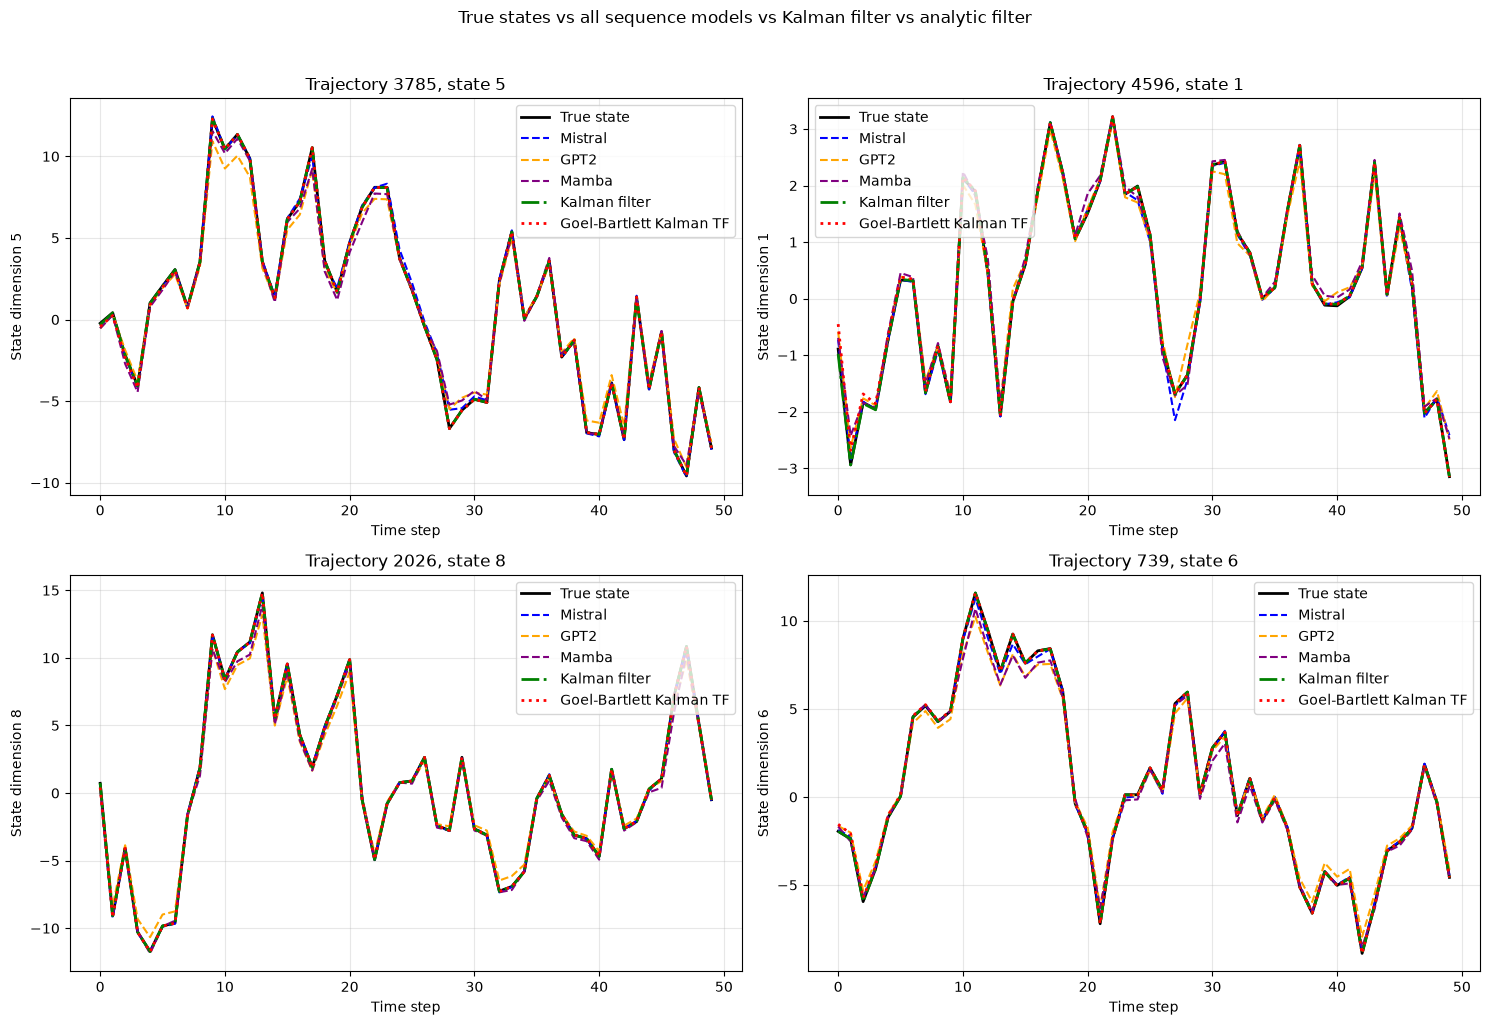

In [28]:
n_shown = min(4, len(test_trajectories))
sampled_indices = rng.choice(len(test_trajectories), size=n_shown, replace=False)
shown_state_dims = {int(i): int(rng.integers(0, CONFIG['nx'])) for i in sampled_indices}

model_colors = {'mistral': 'blue', 'gpt2': 'orange', 'mamba': 'purple'}

plt.figure(figsize=(15, 10))
for k, traj_idx in enumerate(sampled_indices):
    traj_idx = int(traj_idx)
    state_dim = shown_state_dims[traj_idx]
    plt.subplot(2, 2, k + 1)
    plt.plot(test_trajectories[traj_idx]['states'][1:, state_dim],
             label='True state', linewidth=2, color='black')
    for name in trained_models:
        plt.plot(model_predictions[name][traj_idx][:, state_dim], '--',
                 color=model_colors.get(name, 'gray'), linewidth=1.5,
                 label=MODEL_DISPLAY_NAMES[name])
    plt.plot(kf_predictions[traj_idx][:, state_dim], '-.',
             label='Kalman filter', linewidth=2, color='green')
    plt.plot(gb_predictions[traj_idx][:, state_dim], ':', color='red',
             label='Goel-Bartlett Kalman TF', linewidth=2)
    plt.xlabel('Time step')
    plt.ylabel(f'State dimension {state_dim}')
    plt.title(f'Trajectory {traj_idx}, state {state_dim}')
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.suptitle('True states vs all sequence models vs Kalman filter vs analytic filter', y=1.02)
plt.tight_layout()
plt.show()


## 16. Per-time-step error analysis

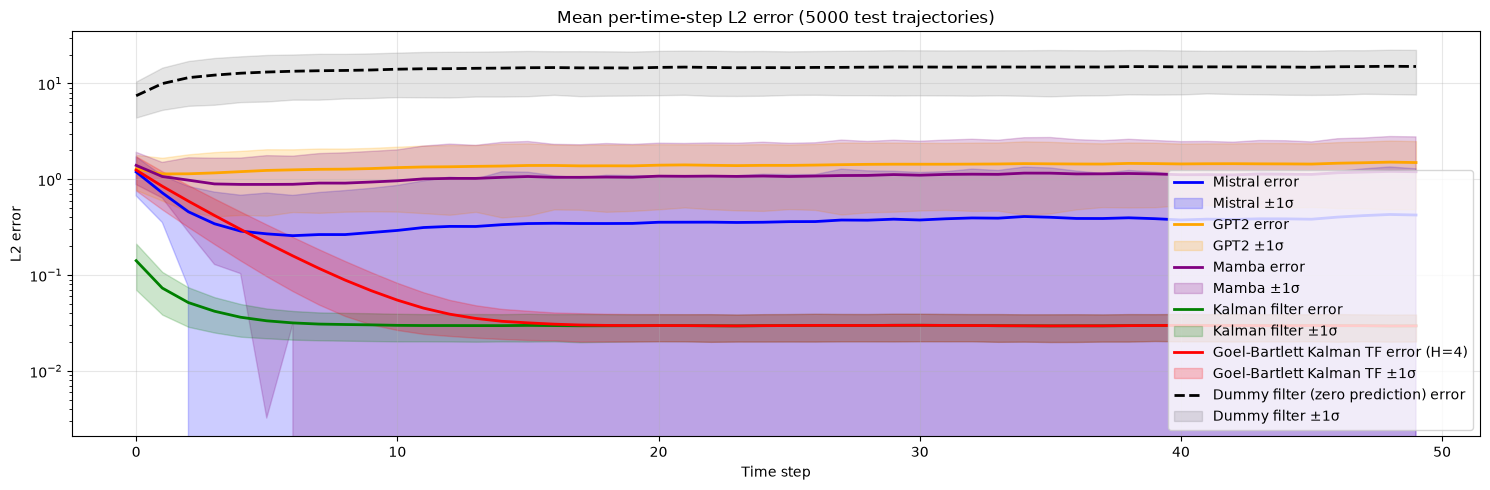


Mean summed L2 error over 5000 test trajectories:
  Mistral: 19.204
  GPT2: 69.205
  Mamba: 53.824
  Kalman filter: 1.692
  Goel-Bartlett Kalman TF (H=4, beta=100000): 5.312
  Dummy filter (zero prediction): 710.786

Theorem 2 gap ||Goel-Bartlett TF - steady-state KF||: mean = 0.00e+00, max = 0.00e+00
(The steady-state KF applies the fixed DARE gain from t=0 with x0=0, while the
filterpy baseline runs the exact time-varying gain from P0=I — the simulator's
true prior — so the analytic filter is slightly worse only in the early transient.)


In [29]:
# Per-time-step L2 error, averaged across all test trajectories.
model_error_curves = {
    name: [per_timestep_l2_errors(s, p)
           for s, p in zip(true_states, model_predictions[name])]
    for name in trained_models
}
kf_error_curves = [per_timestep_l2_errors(s, p) for s, p in zip(true_states, kf_predictions)]
gb_error_curves = [per_timestep_l2_errors(s, p) for s, p in zip(true_states, gb_predictions)]
# Theorem 2 gap: distance from the analytic transformer filter to the
# steady-state Kalman filter (its own H=1 version, same initial condition).
thm2_gap_curves = [per_timestep_l2_errors(x_star, g)
                   for x_star, g in zip(kfstar_predictions, gb_predictions)]

# Dummy filter: predicting zero at every step, whose per-step error is
# exactly the norm of the true state - a scale reference for the curves.
dummy_error_curves = [np.linalg.norm(s, axis=-1) for s in true_states]

model_colors = {'mistral': 'blue', 'gpt2': 'orange', 'mamba': 'purple'}

plt.figure(figsize=(15, 5))
for name in trained_models:
    color = model_colors.get(name, 'gray')
    display_name = MODEL_DISPLAY_NAMES[name]
    mean_err, std_err = mean_std_curves(model_error_curves[name])
    steps = range(len(mean_err))
    plt.semilogy(mean_err, label=f'{display_name} error', linewidth=2, color=color)
    plt.fill_between(steps, mean_err - std_err, mean_err + std_err,
                     color=color, alpha=0.2, label=f'{display_name} ±1σ')

mean_err, std_err = mean_std_curves(kf_error_curves)
steps = range(len(mean_err))
plt.semilogy(mean_err, label='Kalman filter error', linewidth=2, color='green')
plt.fill_between(steps, mean_err - std_err, mean_err + std_err,
                 color='green', alpha=0.2, label='Kalman filter ±1σ')

mean_err, std_err = mean_std_curves(gb_error_curves)
steps = range(len(mean_err))
plt.semilogy(mean_err, label=f'Goel-Bartlett Kalman TF error (H={gb_filter.H})',
             linewidth=2, color='red')
plt.fill_between(steps, mean_err - std_err, mean_err + std_err,
                 color='red', alpha=0.2, label='Goel-Bartlett Kalman TF ±1σ')

mean_err, std_err = mean_std_curves(dummy_error_curves)
steps = range(len(mean_err))
plt.semilogy(mean_err, label='Dummy filter (zero prediction) error',
             linewidth=2, color='black', linestyle='--')
plt.fill_between(steps, mean_err - std_err, mean_err + std_err,
                 color='black', alpha=0.1, label='Dummy filter ±1σ')

plt.xlabel('Time step')
plt.ylabel('L2 error')
plt.title(f'Mean per-time-step L2 error ({len(test_trajectories)} test trajectories)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Trajectory-level summary: sum of the per-time-step L2 errors, averaged over
# trajectories.
print(f"\nMean summed L2 error over {len(test_trajectories)} test trajectories:")
for name in trained_models:
    mean_sum = np.mean([c.sum() for c in model_error_curves[name]])
    print(f"  {MODEL_DISPLAY_NAMES[name]}: {mean_sum:.3f}")
print(f"  Kalman filter: {np.mean([c.sum() for c in kf_error_curves]):.3f}")
print(f"  Goel-Bartlett Kalman TF (H={gb_filter.H}, beta={gb_filter.beta:g}): "
      f"{np.mean([c.sum() for c in gb_error_curves]):.3f}")

print(f"  Dummy filter (zero prediction): "
      f"{np.mean([c.sum() for c in dummy_error_curves]):.3f}")

# Theorem 2 summary (Goel & Bartlett, arXiv:2312.06937): distance from the
# analytic transformer filter to the steady-state Kalman filter.
gap_mean = np.mean([c.mean() for c in thm2_gap_curves])
gap_max = np.max([c.max() for c in thm2_gap_curves])
print(f"\nTheorem 2 gap ||Goel-Bartlett TF - steady-state KF||: "
      f"mean = {gap_mean:.2e}, max = {gap_max:.2e}")
print("(The steady-state KF applies the fixed DARE gain from t=0 with x0=0, while the")
print("filterpy baseline runs the exact time-varying gain from P0=I — the simulator's")
print("true prior — so the analytic filter is slightly worse only in the early transient.)")


## 17. Best and worst state-trajectory pairs


Mistral — best 2 pairs:
  Trajectory 884, state 7: MSE = 0.0007
  Trajectory 854, state 6: MSE = 0.0008
Mistral — worst 2 pairs:
  Trajectory 839, state 8: MSE = 16.2578
  Trajectory 1666, state 8: MSE = 13.5769


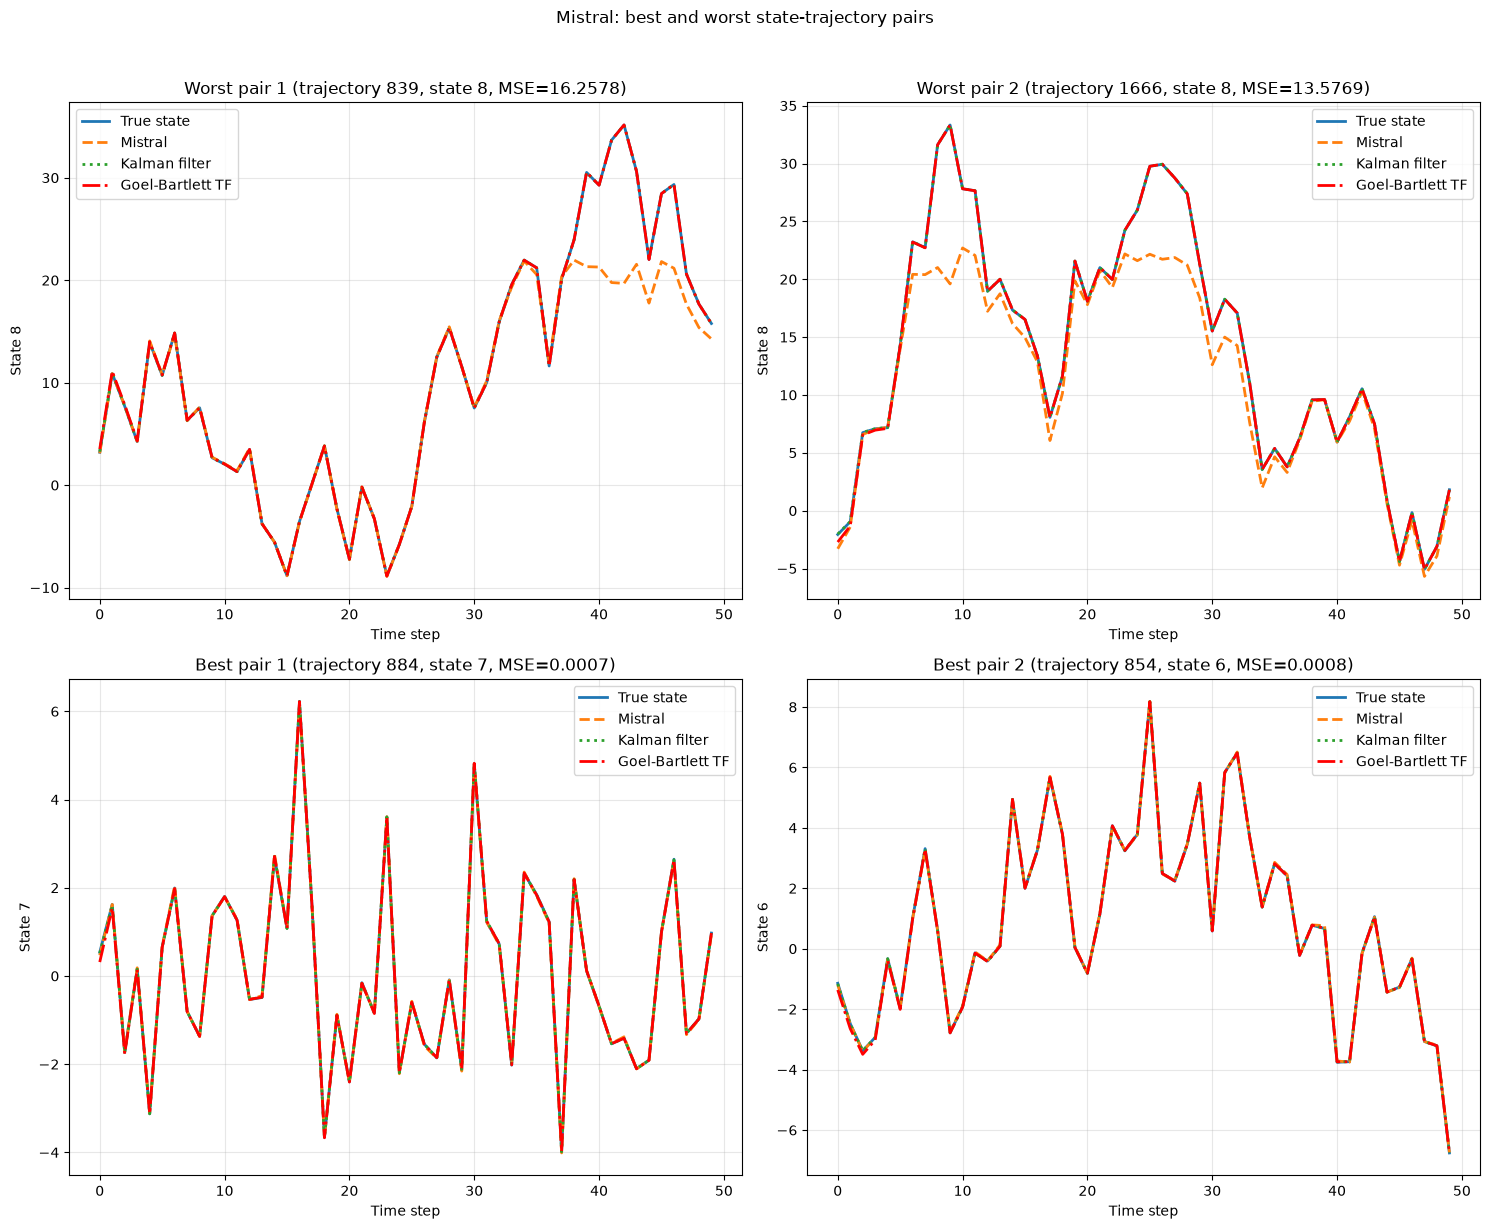


GPT2 — best 2 pairs:
  Trajectory 2021, state 1: MSE = 0.0095
  Trajectory 3734, state 1: MSE = 0.0107
GPT2 — worst 2 pairs:
  Trajectory 839, state 8: MSE = 11.4081
  Trajectory 3066, state 8: MSE = 10.7287


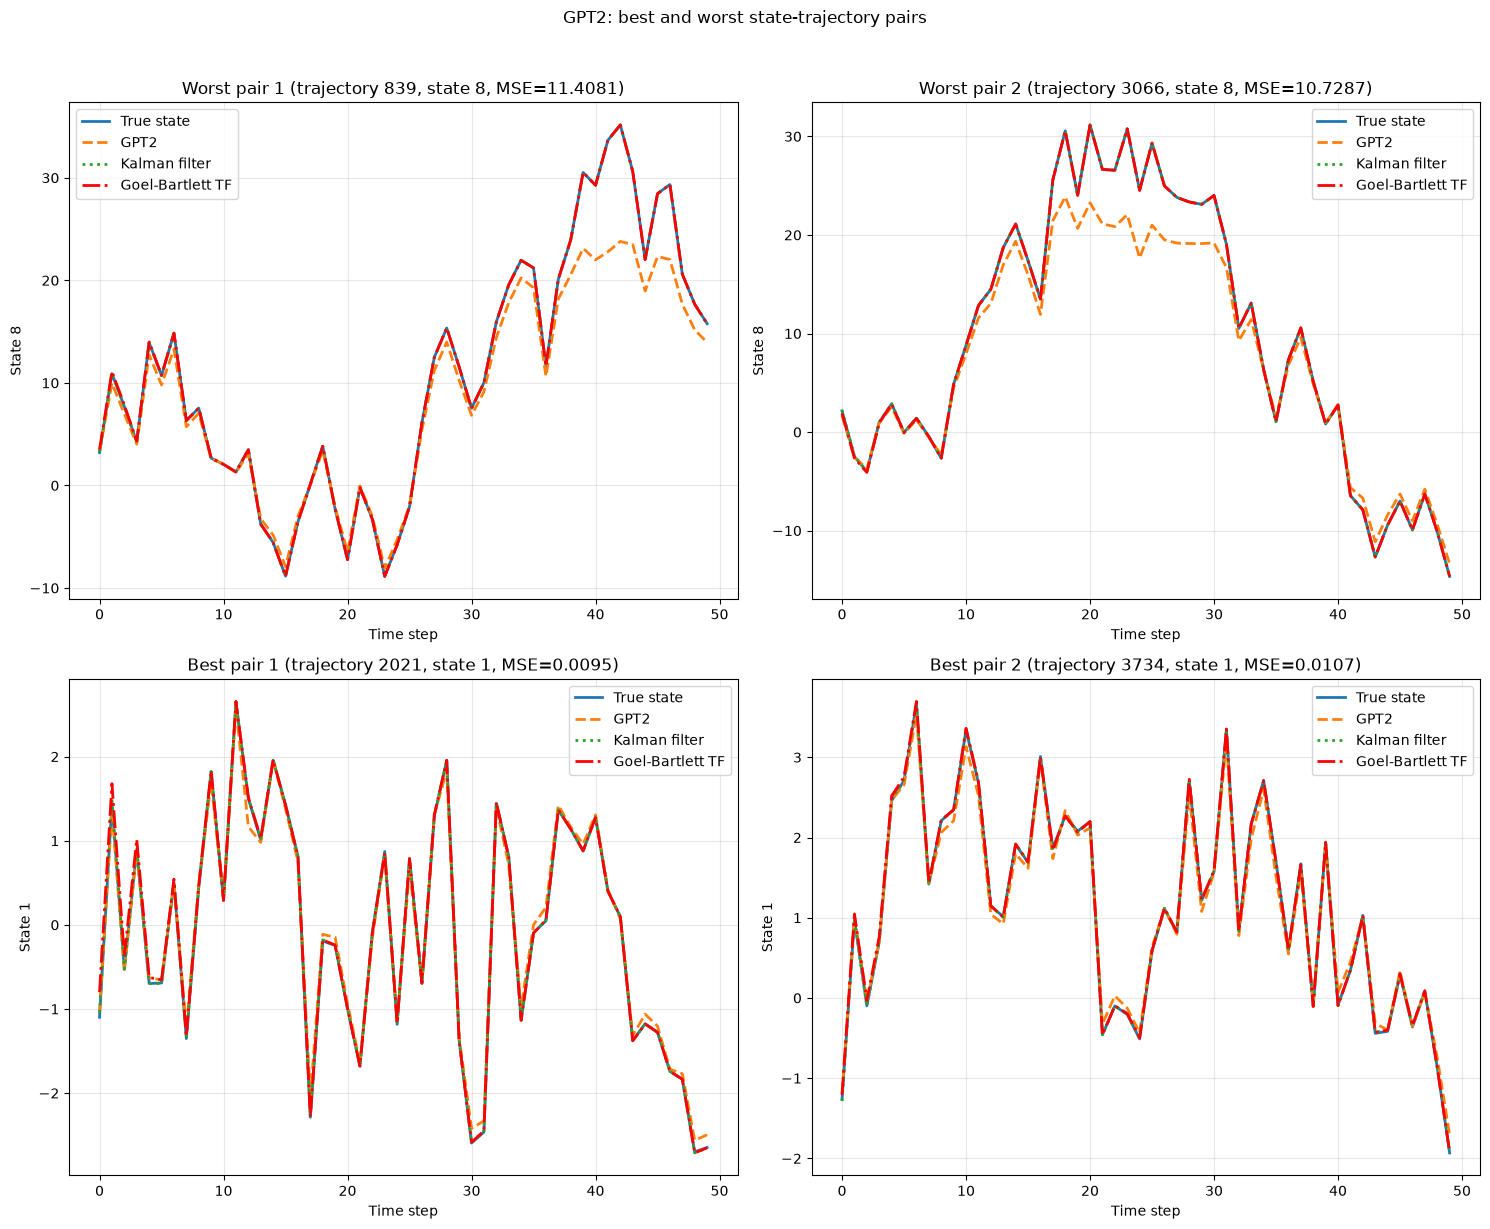


Mamba — best 2 pairs:
  Trajectory 854, state 1: MSE = 0.0115
  Trajectory 2449, state 1: MSE = 0.0118
Mamba — worst 2 pairs:
  Trajectory 1666, state 8: MSE = 31.4380
  Trajectory 839, state 8: MSE = 30.7562


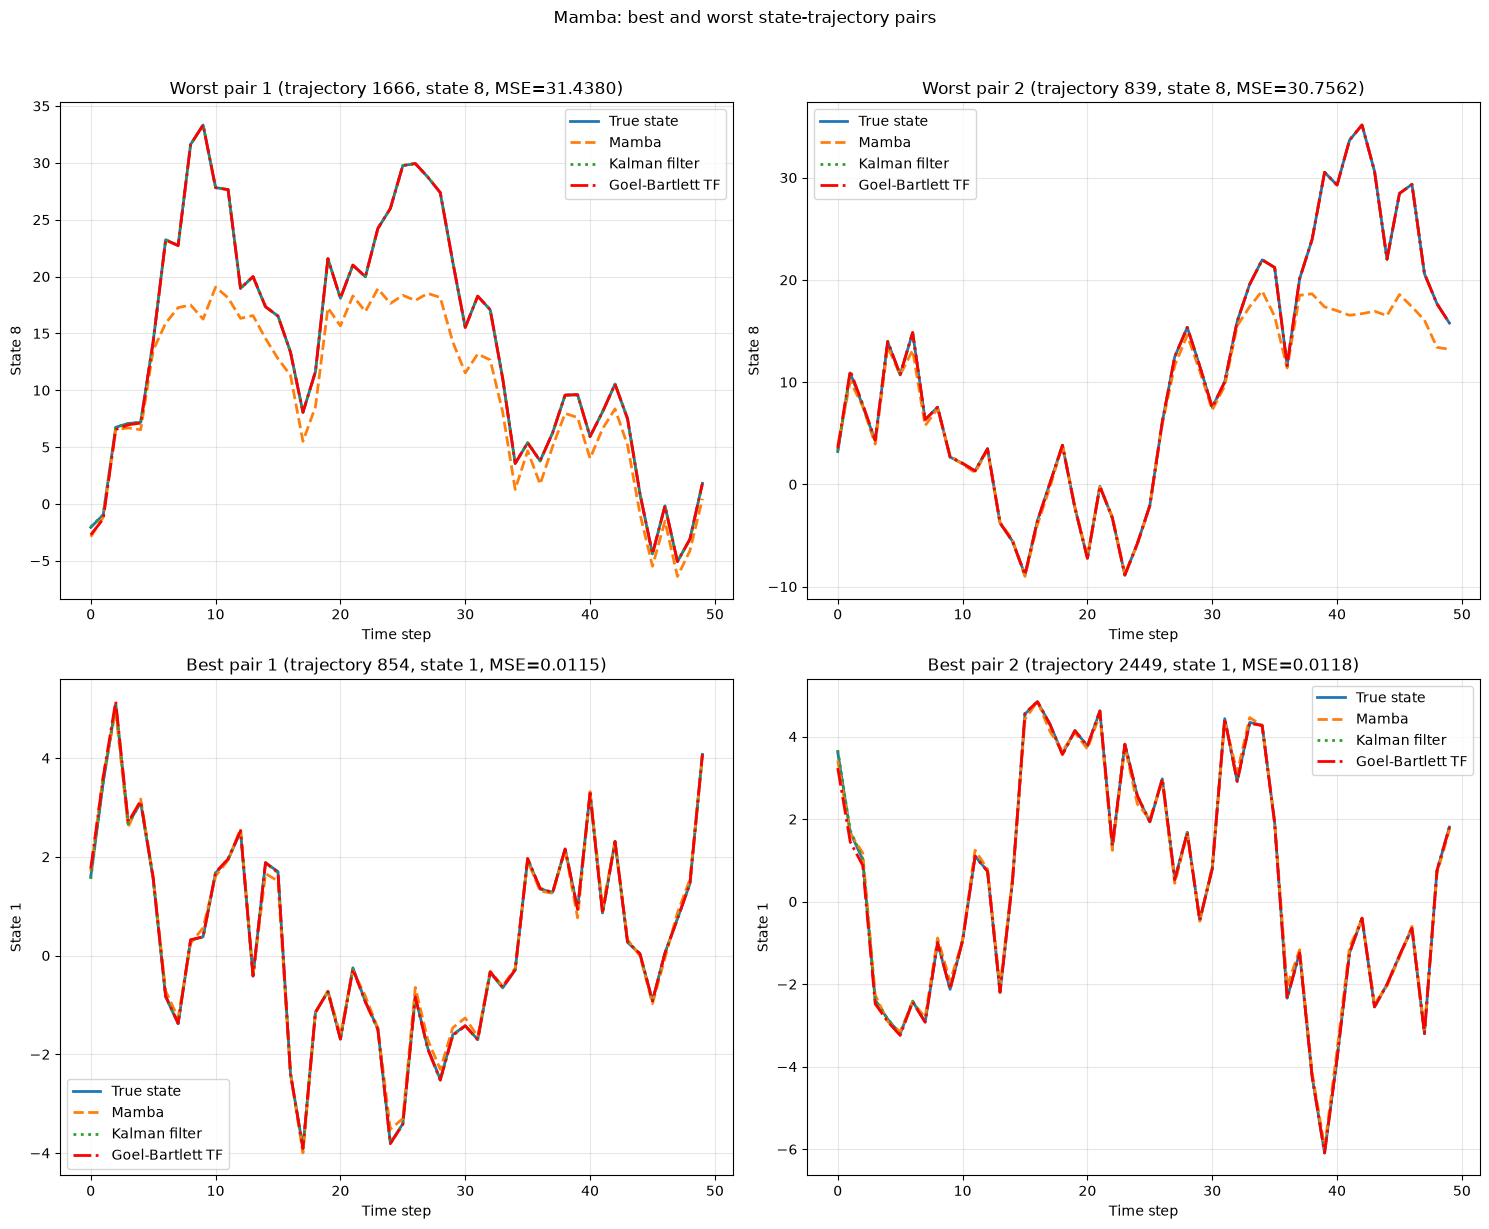

In [18]:
# For each model, the (trajectory, state-dimension) pairs with the lowest and
# highest time-averaged MSE across all test trajectories.
n_best = n_worst = 2

states_all = np.stack(true_states)      # (N, T, nx)
kf_all = np.stack(kf_predictions)       # (N, T, nx)
gb_all = np.stack(gb_predictions)       # (N, T, nx)

for name in trained_models:
    display_name = MODEL_DISPLAY_NAMES[name]
    preds = np.stack(model_predictions[name])
    T = min(preds.shape[1], states_all.shape[1])
    mse = np.mean((states_all[:, :T] - preds[:, :T]) ** 2, axis=1)  # (N, nx)

    order = np.argsort(mse.ravel())
    best_pairs = np.unravel_index(order[:n_best], mse.shape)
    worst_pairs = np.unravel_index(order[-n_worst:][::-1], mse.shape)

    print(f"\n{display_name} — best {n_best} pairs:")
    for traj_idx, state_dim in zip(*best_pairs):
        print(f'  Trajectory {traj_idx}, state {state_dim}: MSE = {mse[traj_idx, state_dim]:.4f}')
    print(f"{display_name} — worst {n_worst} pairs:")
    for traj_idx, state_dim in zip(*worst_pairs):
        print(f'  Trajectory {traj_idx}, state {state_dim}: MSE = {mse[traj_idx, state_dim]:.4f}')

    panels = list(zip(*worst_pairs)) + list(zip(*best_pairs))
    titles = ['Worst pair 1', 'Worst pair 2', 'Best pair 1', 'Best pair 2']
    plt.figure(figsize=(15, 12))
    for k, (traj_idx, state_dim) in enumerate(panels):
        plt.subplot(2, 2, k + 1)
        plt.plot(states_all[traj_idx, :T, state_dim], label='True state', linewidth=2)
        plt.plot(preds[traj_idx, :T, state_dim], '--', label=display_name, linewidth=2)
        plt.plot(kf_all[traj_idx, :T, state_dim], ':', label='Kalman filter', linewidth=2)
        plt.plot(gb_all[traj_idx, :T, state_dim], '-.', color='red',
                 label='Goel-Bartlett TF', linewidth=2)
        plt.xlabel('Time step')
        plt.ylabel(f'State {state_dim}')
        plt.title(f'{titles[k]} (trajectory {traj_idx}, state {state_dim}, '
                  f'MSE={mse[traj_idx, state_dim]:.4f})')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.suptitle(f'{display_name}: best and worst state-trajectory pairs', y=1.02)
    plt.tight_layout()
    plt.show()


## 18. Save / load model checkpoints (optional)

In [19]:
def checkpoint_filename(model_name, config):
    """Canonical checkpoint path for a model trained with this CONFIG."""
    return (f"{model_name}_filter_nx{config['nx']}_ny{config['ny']}"
            f"_sw{config['sigma_w_train']}_sv{config['sigma_v_train']}"
            f"_u{config['input_upper_train']}.pth")


def save_model(model, model_name, config, path=None):
    """Save model weights together with the config needed to rebuild it."""
    path = checkpoint_filename(model_name, config) if path is None else path
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config,
        'model_name': model_name,
    }, path)
    print(f"Saved {model_name} to {path}")


def load_model(path, device=DEVICE):
    """Load a model saved by save_model().

    weights_only=False is required because the checkpoint pickles the CONFIG
    dict; only load checkpoint files you trust.
    """
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    config = checkpoint['config']
    model_name = checkpoint['model_name']
    model = build_model(model_name, config['ny'] + config['nx'], config['nx'], config)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    print(f"Loaded {model_name} from {path}")
    return model


# # Save every trained model, then reload it from disk (round-trip check).
# for name, model in trained_models.items():
#     save_model(model, name, CONFIG)

# loaded_models = {}
# for name in trained_models:
#     try:
#         loaded_models[name] = load_model(checkpoint_filename(name, CONFIG))
#     except FileNotFoundError:
#         print(f"No saved checkpoint found for {name}")

# # Keep the in-memory models for anything that was not reloaded from disk.
# trained_models.update(loaded_models)
# print(f"{len(loaded_models)} model(s) reloaded from disk")